## Load and join the raw tables

In [2]:
# imports and load
import pandas as pd
import numpy as np

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

In [3]:
# filter to delivered orders and join the customer key
print(f"Orders before filtering: {len(orders):,}")
orders = orders[orders["order_status"] == "delivered"].copy()
print(f"Orders after filtering to delivered: {len(orders):,}")

orders = orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")

Orders before filtering: 99,441
Orders after filtering to delivered: 96,478


In [4]:
# order-level revenue
order_value = items.groupby("order_id").agg(
    order_revenue=("price", "sum"),
    n_items=("order_item_id", "count")
).reset_index()

txn = orders.merge(order_value, on="order_id")
print(f"Transactions ready: {len(txn):,} rows, {txn['customer_unique_id'].nunique():,} unique customers")

Transactions ready: 96,478 rows, 93,358 unique customers


In [5]:
# the sanity checks — run these and actually read the output before moving on
orders_per_customer = txn.groupby("customer_unique_id")["order_id"].nunique()
print(orders_per_customer.value_counts().sort_index())
print(f"\n% of customers who ordered exactly once: {(orders_per_customer == 1).mean()*100:.1f}%")
print(f"\nDate range: {txn['order_purchase_timestamp'].min()} to {txn['order_purchase_timestamp'].max()}")

order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

% of customers who ordered exactly once: 97.0%

Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


## RFM Feature Engineering

In [6]:
# Recency, Frequency, Monetary
snapshot_date = txn["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = txn.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("order_revenue", "sum"),
    avg_order_value=("order_revenue", "mean"),
    avg_items_per_order=("n_items", "mean"),
).reset_index()

rfm.describe()

,recency,frequency,monetary,avg_order_value,avg_items_per_order
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480,137.508262,1.139531
std,152.591453,0.209097,215.694014,209.860279,0.527075
min,1.000000,1.000000,0.850000,0.850000,1.000000
25%,114.000000,1.000000,47.650000,46.000000,1.000000
50%,219.000000,1.000000,89.730000,86.990000,1.000000
75%,346.000000,1.000000,154.737500,149.900000,1.000000
max,714.000000,15.000000,13440.000000,13440.000000,21.000000


In [7]:
# payment behavior — installment preference
pay_features = payments.groupby("order_id").agg(
    avg_installments=("payment_installments", "mean"),
).reset_index()

txn_pay = txn.merge(pay_features, on="order_id")
installment_pref = txn_pay.groupby("customer_unique_id")["avg_installments"].mean().reset_index()

rfm = rfm.merge(installment_pref, on="customer_unique_id", how="left")

In [8]:
# category diversity
items_products = items.merge(products[["product_id", "product_category_name"]], on="product_id")
items_products = items_products.merge(orders[["order_id", "customer_unique_id"]], on="order_id")

category_diversity = items_products.groupby("customer_unique_id")["product_category_name"].nunique().reset_index()
category_diversity.columns = ["customer_unique_id", "category_diversity"]

rfm = rfm.merge(category_diversity, on="customer_unique_id", how="left")

In [9]:
# review score (satisfaction proxy)
review_by_order = reviews.groupby("order_id")["review_score"].mean().reset_index()
txn_review = txn.merge(review_by_order, on="order_id", how="left")
avg_review = txn_review.groupby("customer_unique_id")["review_score"].mean().reset_index()

rfm = rfm.merge(avg_review, on="customer_unique_id", how="left")

In [10]:
# check for missing values before moving on
print(rfm.isnull().sum())
print(f"\nTotal customers: {len(rfm):,}")

customer_unique_id       0
recency                  0
frequency                0
monetary                 0
avg_order_value          0
avg_items_per_order      0
avg_installments         1
category_diversity       0
review_score           603
dtype: int64

Total customers: 93,358


In [11]:
rfm["avg_installments"] = rfm["avg_installments"].fillna(1)
rfm["review_score"] = rfm["review_score"].fillna(rfm["review_score"].median())
rfm["category_diversity"] = rfm["category_diversity"].fillna(1)

## Handle skew (log-transform)

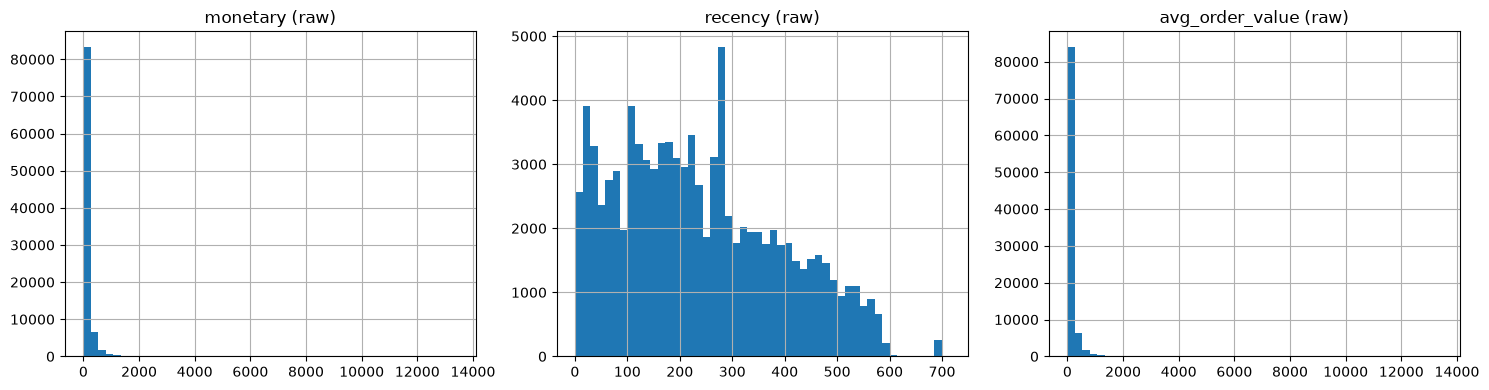

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm["monetary"].hist(bins=50, ax=axes[0])
axes[0].set_title("monetary (raw)")
rfm["recency"].hist(bins=50, ax=axes[1])
axes[1].set_title("recency (raw)")
rfm["avg_order_value"].hist(bins=50, ax=axes[2])
axes[2].set_title("avg_order_value (raw)")
plt.tight_layout()
plt.savefig("../outputs/rfm_distributions_raw.png", dpi=150)
plt.show()

In [13]:
for col in ["monetary", "avg_order_value", "recency"]:
    rfm[f"{col}_log"] = np.log1p(rfm[col])

In [14]:
rfm[["recency","frequency","monetary","category_diversity","avg_installments","review_score"]].describe()

,recency,frequency,monetary,category_diversity,avg_installments,review_score
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480,1.011193,2.899743,4.159109
std,152.591453,0.209097,215.694014,0.204214,2.675894,1.277817
min,1.000000,1.000000,0.850000,0.000000,0.000000,1.000000
25%,114.000000,1.000000,47.650000,1.000000,1.000000,4.000000
50%,219.000000,1.000000,89.730000,1.000000,2.000000,5.000000
75%,346.000000,1.000000,154.737500,1.000000,4.000000,5.000000
max,714.000000,15.000000,13440.000000,5.000000,24.000000,5.000000


In [15]:
print(f"Customers with category_diversity=0: {(rfm['category_diversity']==0).sum()}")
rfm.loc[rfm["category_diversity"] == 0, "category_diversity"] = 1

Customers with category_diversity=0: 1260


In [16]:
zero_installment_orders = txn_pay[txn_pay["avg_installments"] == 0]
print(zero_installment_orders.shape[0])

2


In [17]:
rfm[["recency","frequency","monetary","category_diversity","avg_installments","review_score"]].describe()

,recency,frequency,monetary,category_diversity,avg_installments,review_score
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480,1.024690,2.899743,4.159109
std,152.591453,0.209097,215.694014,0.166501,2.675894,1.277817
min,1.000000,1.000000,0.850000,1.000000,0.000000,1.000000
25%,114.000000,1.000000,47.650000,1.000000,1.000000,4.000000
50%,219.000000,1.000000,89.730000,1.000000,2.000000,5.000000
75%,346.000000,1.000000,154.737500,1.000000,4.000000,5.000000
max,714.000000,15.000000,13440.000000,5.000000,24.000000,5.000000


In [18]:
rfm.to_csv("../data/processed/rfm_features.csv", index=False)

In [19]:
# pick the feature set going into clustering
feature_cols = [
    "recency_log", "frequency", "monetary_log", "avg_order_value_log",
    "avg_items_per_order", "avg_installments", "category_diversity", "review_score"
]

X = rfm[feature_cols].copy()
X.isnull().sum()  # should all be zero at this point — if not, go back and handle it before scaling

recency_log            0
frequency              0
monetary_log           0
avg_order_value_log    0
avg_items_per_order    0
avg_installments       0
category_diversity     0
review_score           0
dtype: int64

In [20]:
# scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.describe()

,recency_log,frequency,monetary_log,avg_order_value_log,avg_items_per_order,avg_installments,category_diversity,review_score
count,9.335800e+04,9.335800e+04,9.335800e+04,9.335800e+04,9.335800e+04,9.335800e+04,9.335800e+04,9.335800e+04
mean,-7.501349e-16,-1.902737e-18,5.096290e-16,3.592367e-17,1.619609e-16,-1.491745e-16,-4.944071e-16,-1.653098e-16
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-4.794069e+00,-1.598294e-01,-4.191407e+00,-4.213765e+00,-2.647278e-01,-1.083660e+00,-1.482878e-01,-2.472283e+00
25%,-4.515947e-01,-1.598294e-01,-6.509581e-01,-6.720556e-01,-2.647278e-01,-7.099509e-01,-1.482878e-01,-1.245170e-01
50%,2.436404e-01,-1.598294e-01,2.393372e-02,1.448090e-02,-2.647278e-01,-3.362420e-01,-1.482878e-01,6.580716e-01
75%,7.320309e-01,-1.598294e-01,6.089979e-01,6.050219e-01,-2.647278e-01,4.111758e-01,-1.482878e-01,6.580716e-01
max,1.506856e+00,6.679496e+01,5.436374e+00,5.520171e+00,3.768077e+01,7.885354e+00,2.387575e+01,6.580716e-01


In [21]:
import joblib

joblib.dump(scaler, "../data/processed/scaler.pkl")
np.save("../data/processed/X_scaled.npy", X_scaled)

print(f"Scaled feature matrix shape: {X_scaled.shape}")

Scaled feature matrix shape: (93358, 8)
